In [174]:
# remember to reference Tim's code

In [175]:
from Modules.brute_force_bond_finder import brute_force_bond_finder
from Modules.moebius_machinery import mat_vec_mu_graph
import scipy
import numpy as np
import itertools
import networkx as nx
from Modules.moebius_machinery import mat_vec_solve_mu
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
import sys
sys.path.insert(0, '../szzoli-ite-in-python-44a8f15e2dc9')
from ite.cost.x_factory import co_factory


In [177]:
cost = 'BDTsallis_KnnK'
co = co_factory(cost, mult=True, alpha=0.5, k=5)

In [178]:
# Taken from Tim's repo

def shuffle_data(data, shuffle_indices):
    # Create a copy of the original data to avoid modifying the input in place.
    shuffled_data = data.copy()

    for indices in shuffle_indices:
        # Generate a random permutation for the indices.
        permutation = np.random.permutation(shuffled_data.shape[0])

        # Apply the permutation to the specified indices.
        for idx in indices:
            shuffled_data[:, idx] = shuffled_data[permutation, idx]

    return shuffled_data

In [179]:
def div_simplifier(bond):

    """
        Simplifies the argument of the divergence by cancelling singleton indices appearing in both numerator and denominator.
    """

    numerator = []

    for block in bond:
        if len(block) != 1:
            numerator.append(block)

    # Turn the correct indices into singletons for fully factorised denominator
    denominator = [[i] for block in numerator for i in block]

    return numerator, denominator

In [180]:
def bond_information(G, X, div, algo):
    
    """
        Calculates the bond information for a given graph G, dataset X, divergence measure div, and bond finding algorithm algo.
    """

    # Retrieve all bonds of the graph and initialise array for divergence storing
    #bonds = algo(G)

    # Calculate the mu coefficients of the given graph
    bonds, _, mu = mat_vec_mu_graph(G, algo)
    divs = np.zeros(len(bonds))

    # Check that shapes match
    assert mu.shape[0] == len(bonds)

    # Data shuffling for denominator
    indices = [[i] for i in range(X.shape[1])]
    X_shuffled_denom = shuffle_data(X, indices)

    # Loop over all bonds
    for i, bond in enumerate(bonds):

        # Simplify the argument of the divergence (remove singleton indices)
        num, denom = div_simplifier(bond)

        # Introduce required numerator independence
        X_shuffled_num = shuffle_data(X, num)

        # Turn denom into one list for indexing
        denom_one_list = [i for block in denom for i in block]

        # Guard against pure singleton case
        if len(denom_one_list) == 0:
            divs[i] = 0.0

        else:
            # Calculate divergence
            divs[i] = div(X_shuffled_num[:, denom_one_list], X_shuffled_denom[:, denom_one_list])
        
    # Return sum of divergences weighted by mu's
    return np.sum(mu * divs)

In [181]:
def is_psd(cov):

    """
        Checks that the covariance matrix is positive semidefinite
    """
    return np.all(np.linalg.eigvalsh(cov) >= 0)

In [182]:
# for practicing generating synthetic data, probably won't ever actually use this

def covariance_matrix_graph(G, rho):

    """
        Generate covariance matrix that respects the independence structure introduced by the graph G. The correlation strength between
        variables is rho.
    """

    cov = np.zeros((len(list(G.nodes)), len(list(G.nodes))))
    for e in G.edges:
        cov[e[0], e[1]] = rho
        cov[e[1], e[0]] = rho

    for i in range(len(list(G.nodes))):
        cov[i, i] = 1

    #if is_psd(cov) == False:
        #return print("Invalid covariance matrix")

    return cov

In [183]:
def generate_gaussian(cov, n_samples):

    """
        Generates multivariate Gaussian data that respects the independence/factorisation structure induced by the covariance matrix cov
    """

    # Zero mean for each variable
    mean = np.zeros(cov.shape[0])
    
    # Return data
    return np.random.multivariate_normal(mean, cov, n_samples)

In [246]:
def covariance_matrix_bond(d, bond, rho):

    """
        Generates the covariance matrix respecting the factorisation structure of a given bond. d is the number of variables,
        rho is the correlation strength between dependent variables
    """

    cov = np.zeros((d, d))

    # Loop over all blocks
    for block in bond:

        # Generate all pairs in the block
        if len(block) > 1:
            pairs = itertools.combinations(block, 2)

            # Fill in covariance matrix entries
            for pair in pairs:
                cov[pair[0], pair[1]] = rho
                cov[pair[1], pair[0]] = rho

    for i in range(d):
        cov[i, i] = 1

    return cov

In [247]:
def set_maker(pi):

    """
        Turns a list of lists into a frozen set of a frozen sets.
    """

    return frozenset(frozenset(block) for block in pi)

In [248]:

def zeta_matrix(partitions):

    """
        Calculates the zeta matrix for any partition lattice or sublattice, ordered by refinement
    """

    # Turn partitions and blocks within partitions into frozen sets so that set inclusion operations work
    bonds = [set_maker(pi) for pi in partitions]

    # Get number of bonds and initialise zeta matrix
    n = len(partitions)
    zeta = np.zeros((n, n))

    # Refinement check / filling in zeta matrix
    for i, pi in enumerate(bonds):
        for j, sigma in enumerate(bonds): # can possibly simplify further by working out how many bonds at each rank, then checking less bonds
            verdict = all(any(b <= B for B in sigma) for b in pi)
            #print(pi, sigma, verdict)
            if verdict == True:
                zeta[i, j] = 1

    return zeta

In [270]:
def analytic_gaussian_bi_old(G, algo, rho, alpha=0.5):

    """
        G the graph, algo the bond-finding algorithm, rho specifies the correlation strength of the dependent factorisations induced by bonds
        (0 means complete independence) alpha the specified parameter for the TA divergence (normally 0.5). This function 
        calculates the analytic bond information for some graph G when the dataset is multivariate FULLY Gaussian
    """

    # Get bonds and moebius coefficients
    bonds = algo(G)
    d = len(bonds[0])
    _, _, mu = mat_vec_solve_mu(bonds)

    # Initialise running sum
    sum = 0.0

    # Main calculation loop
    for i, bond in enumerate(bonds):
        cov = covariance_matrix_bond(d, bond, rho)
        div = ((np.linalg.det(np.linalg.inv(cov))) ** (alpha / 2)) / (np.linalg.det(alpha * np.linalg.inv(cov) + (1 - alpha) * np.eye(cov.shape[0]))) ** (1/2)
        sum += mu[i] * ((div - 1.0) / (alpha - 1.0))

    
    return sum

In [250]:
def restrict(sigma, bond):

    """
        Restricts a known covariance matrix giving factorisation structure of a joint (Gaussian) distribution to give the covariance for
        factorisation restricted by some given bond
    """

    # Copy to prevent overwriting
    sigma_bond = sigma.copy()

    # Number of variables
    d = sigma.shape[0]

    # Update covariance to match bond factorisation structure
    for block in bond:
        for i in block:
            for j in range(d):
                if j not in block:
                    sigma_bond[i, j] = 0

    return sigma_bond

In [259]:
def analytic_gaussian_bi(G, algo, sigma, alpha=0.5):

    """
        G the graph, algo the bond-finding algorithm, sigma gives the factorisation structure of the joint, alpha the specified parameter for 
        the TA divergence (normally 0.5). This function calculates the analytic bond information for some graph G when the dataset is
        multivariate Gaussian that factorises according to the covariance matrix sigma
    """

    # Get bonds and moebius coefficients
    bonds = algo(G)
    d = len(bonds[0])
    _, _, mu = mat_vec_solve_mu(bonds)

    # Initialise running sum
    sum = 0.0

    # Main calculation loop
    for i, bond in enumerate(bonds):
        cov_pi = restrict(sigma, bond)
        div = ((np.linalg.det(np.linalg.inv(cov_pi))) ** (alpha / 2)) / (np.linalg.det(alpha * np.linalg.inv(cov_pi) + (1 - alpha) * np.eye(cov_pi.shape[0]))) ** (1/2)
        sum += mu[i] * ((div - 1.0) / (alpha - 1.0))
        print(mu[i] * ((div - 1.0) / (alpha - 1.0)))

    return sum

In [269]:
K_4 = nx.complete_graph(4)
P_4 = nx.path_graph(4)
C_4 = nx.cycle_graph(4)
bonds_K_4 = brute_force_bond_finder(K_4)
bonds_P_4 = brute_force_bond_finder(P_4)
bonds_C_4 = brute_force_bond_finder(C_4)
print(bonds_C_4)

K_4_list = []
P_4_list = []
C_4_list = []

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]


In [268]:
K_4_list = []
P_4_list = []
C_4_list = []

for rho in np.arange(0, 1, 0.1):
    sigma = covariance_matrix_bond(4, [[0, 2], [1, 3]], rho)


    #K_4_list.append(analytic_gaussian_bi(K_4, brute_force_bond_finder, sigma))
    #P_4_list.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))
    C_4_list.append(analytic_gaussian_bi(C_4, brute_force_bond_finder, sigma))

#print(K_4_list)
#print(P_4_list)
print(C_4_list)

0.0
-0.0
-0.0
-0.0
-0.0
0.0
0.0
0.0
0.0
0.0
0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0025204482082819
0.0
-0.0025204482082819
-0.0025204482082819
0.0
-0.0025204482082819
0.005037720086978004
0.0
-0.0
-0.0
-0.0
-0.0
-0.01033387185996415
0.0
-0.01033387185996415
-0.01033387185996415
0.0
-0.01033387185996415
0.020614349266119047
0.0
-0.0
-0.0
-0.0
-0.0
-0.024250136029404068
0.0
-0.024250136029404068
-0.024250136029404068
0.0
-0.024250136029404068
0.04820623751008579
0.0
-0.0
-0.0
-0.0
-0.0
-0.045821635794248916
0.0
-0.045821635794248916
-0.045821635794248916
0.0
-0.045821635794248916
0.09059346043506755
0.0
-0.0
-0.0
-0.0
-0.0
-0.07775086869219616
0.0
-0.07775086869219616
-0.07775086869219616
0.0
-0.07775086869219616
0.15247913859319695
0.0
-0.0
-0.0
-0.0
-0.0
-0.12477107624601813
0.0
-0.12477107624601813
-0.12477107624601813
0.0
-0.12477107624601813
0.24175824175824157
0.0
-0.0
-0.0
-0.0
-0.0
-0.1957405978576794
0.0
-0.1957405978576794
-0.1957405978576794
0.0
-0.1957405978576794
0.37232400489

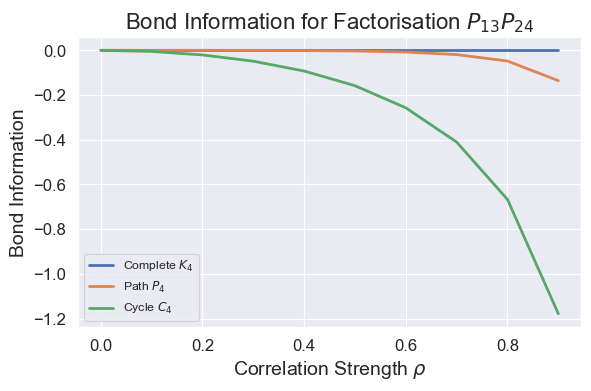

In [262]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 4))

# Plot with matplotlib
ax.plot(np.arange(0, 1, 0.1), K_4_list,
        linewidth=2,
        markersize=5, label=r"Complete $K_4$")
ax.plot(np.arange(0, 1, 0.1), P_4_list,
        linewidth=2,
        markersize=5, label=r"Path $P_4$")
ax.plot(np.arange(0, 1, 0.1), C_4_list,
        linewidth=2,
        markersize=5, label=r"Cycle $C_4$")

# Customize with matplotlib
ax.set_xlabel(r"Correlation Strength $\rho$", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend()
ax.set_title(r"Bond Information for Factorisation $P_{13}P_{24}$", fontsize=16)

plt.tight_layout()
plt.savefig("figure.pdf", bbox_inches="tight")

In [224]:
print(bonds_P_4)
print(bonds_C_4)

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[0, 1, 2, 3]]]
[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]


In [265]:
K_4_list_2 = []
P_4_list_2 = []
C_4_list_2 = []

for rho in np.arange(0, 1, 0.1):
    sigma = covariance_matrix_bond(4, [[0], [1, 2, 3]], rho)


    #K_4_list_2.append(analytic_gaussian_bi(K_4, brute_force_bond_finder, sigma))
    P_4_list_2.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))
    #C_4_list_2.append(analytic_gaussian_bi(C_4, brute_force_bond_finder, sigma))

#print(K_4_list_2)
print(P_4_list_2)
#print(C_4_list_2)

0.0
-0.0
-0.0
-0.0
0.0
0.0
0.0
-0.0
0.0
0.0025204482082819
0.0025204482082819
-0.0
-0.006911358986639415
-0.0025204482082819
-0.0025204482082819
0.006911358986639415
0.0
0.01033387185996415
0.01033387185996415
-0.0
-0.026333064051241584
-0.01033387185996415
-0.01033387185996415
0.026333064051241584
0.0
0.024250136029404068
0.024250136029404068
-0.0
-0.05813779302867483
-0.024250136029404068
-0.024250136029404068
0.05813779302867483
0.0
0.045821635794248916
0.045821635794248916
-0.0
-0.10429942287167582
-0.045821635794248916
-0.045821635794248916
0.10429942287167582
0.0
0.07775086869219616
0.07775086869219616
-0.0
-0.16909587208256216
-0.07775086869219616
-0.07775086869219616
0.16909587208256216
0.0
0.12477107624601813
0.12477107624601813
-0.0
-0.2601667348129906
-0.12477107624601813
-0.12477107624601813
0.2601667348129906
0.0
0.1957405978576794
0.1957405978576794
-0.0
-0.39118681772754726
-0.1957405978576794
-0.1957405978576794
0.39118681772754726
0.0
0.30969149054296663
0.309691490542

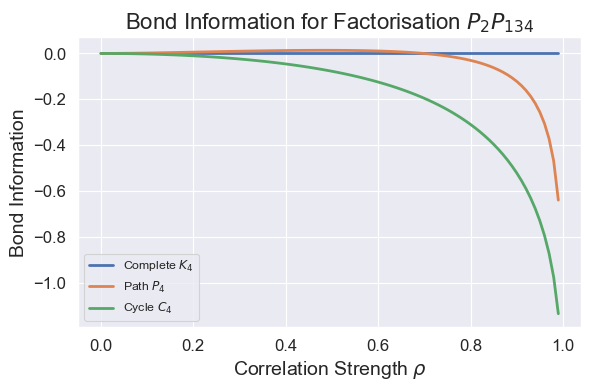

In [231]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 4))

# Plot with matplotlib
ax.plot(np.arange(0, 1, 0.01), K_4_list_2,
        linewidth=2,
        markersize=5, label=r"Complete $K_4$")
ax.plot(np.arange(0, 1, 0.01), P_4_list_2,
        linewidth=2,
        markersize=5, label=r"Path $P_4$")
ax.plot(np.arange(0, 1, 0.01), C_4_list_2,
        linewidth=2,
        markersize=5, label=r"Cycle $C_4$")

# Customize with matplotlib
ax.set_xlabel(r"Correlation Strength $\rho$", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend()
ax.set_title(r"Bond Information for Factorisation $P_{2}P_{134}$", fontsize=16)

plt.tight_layout()
plt.savefig("figure.pdf", bbox_inches="tight")

In [233]:
C_4_list_3 = []

bonds = brute_force_bond_finder(C_4)
for bond in bonds:
    sigma = covariance_matrix_bond(4, bond, 0.5)
    C_4_list_3.append(analytic_gaussian_bi(C_4, brute_force_bond_finder, sigma))

print(bonds)
print(C_4_list_3)

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(-0.07775086869219616), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(-0.09966471573937885)]


In [195]:
# Issues with k too large

cost = 'BDTsallis_KnnK'
co = co_factory(cost, mult=True, alpha=0.5, k=30)

In [196]:
# Making Streitberg
K_4 = nx.complete_graph(4)
bonds = brute_force_bond_finder(K_4)
cov = covariance_matrix_bond(4, [[0, 2], [1, 3]], 0.5)

P_4 = nx.path_graph(4)
print(bonds[-1])

[[0, 1, 2, 3]]


In [197]:
print("Path-induced bond information:")
print(bond_information(P_4, generate_gaussian(cov, 500), co.estimation, brute_force_bond_finder))
print("Completegraph-induced bond information (streitberg):")
print(bond_information(K_4, generate_gaussian(cov, 500), co.estimation, brute_force_bond_finder))

Path-induced bond information:
-0.02413269558765685
Completegraph-induced bond information (streitberg):
-0.09139899426433762


In [198]:
K_3 = nx.complete_graph(3)
bonds = brute_force_bond_finder(K_3)
cov = covariance_matrix_bond(3, bonds[2], 0.5)

for n in [500, 1000, 2000, 5000]:
    results = [bond_information(K_3, generate_gaussian(cov, n), co.estimation, brute_force_bond_finder) 
               for _ in range(100)]
    print(f"n={n}: mean={np.mean(results):.4f}, |mean|={abs(np.mean(results)):.4f}")

n=500: mean=0.0138, |mean|=0.0138
n=1000: mean=0.0141, |mean|=0.0141


c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:188: SyntaxWarning: invalid escape sequence '\i'
  as \int p^{1/2}(x)q^{1/2}(x)dx = \int p^{-1/2}(x)q^{1/2}(x)
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:339: SyntaxWarning: invalid escape sequence '\i'
  divergence as \int p^2(x)q^{-1}(x)dx - 1 =
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:435: SyntaxWarning: invalid escape sequence '\i'
  divergence as \int p^{1/2}(x)q^{1/2}(x)dx =
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\shared.py:150: SyntaxWarning: invalid escape sequence '\i'
  """ Estimate i_alpha = \int p^{\alpha}(y)dy.
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\shared.py:232: SyntaxWarning: invalid escape sequence '\i'
  """ Estimate d_temp1 = \int p^{\alpha}(u)q^{1-\alpha}(u)du.
c:\Users\morit\Thesis_Repo\Notebooks\.

KeyboardInterrupt: 